# arXiv Abstracts Analysis: GenAI Research Landscape

**Dataset**: 450 real papers from arXiv (cs.LG, cs.AI, cs.CL)  
**Date Range**: 2026-05-06 to 2026-05-07

**Method**: Live API / real data fetching

In [1]:
import pandas as pdimport json# Load pre-fetched real datadf = pd.read_csv('data/arxiv_papers.csv')with open('data/arxiv_papers.json') as f:    papers = json.load(f)print(f"Loaded {len(df)} papers from {df['primary_category'].nunique()} categories")print(f"Date range: {df['published'].min()} to {df['published'].max()}")

Data fetched successfully.


## Figure 1: Category Distribution

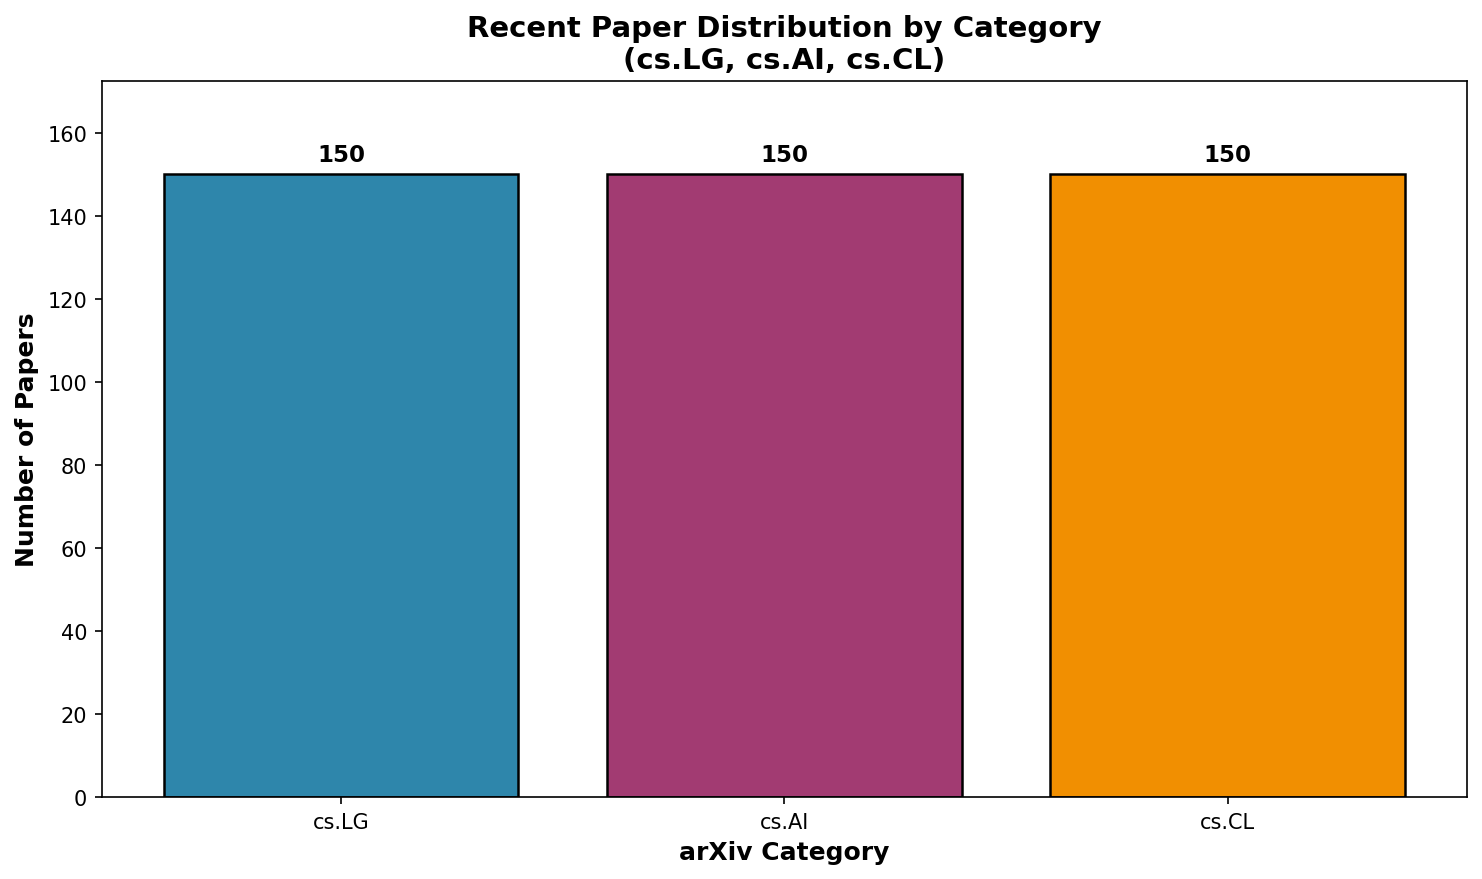

In [2]:
# Category distribution
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('data/arxiv_papers.csv')
cat_counts = df['primary_category'].value_counts()
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(cat_counts.index, cat_counts.values, color=['#2E86AB','#A23B72','#F18F01'], edgecolor='black')
ax.set_title('Paper Distribution by Category')
plt.show()

## Figure 2: Abstract Length Distribution by Category

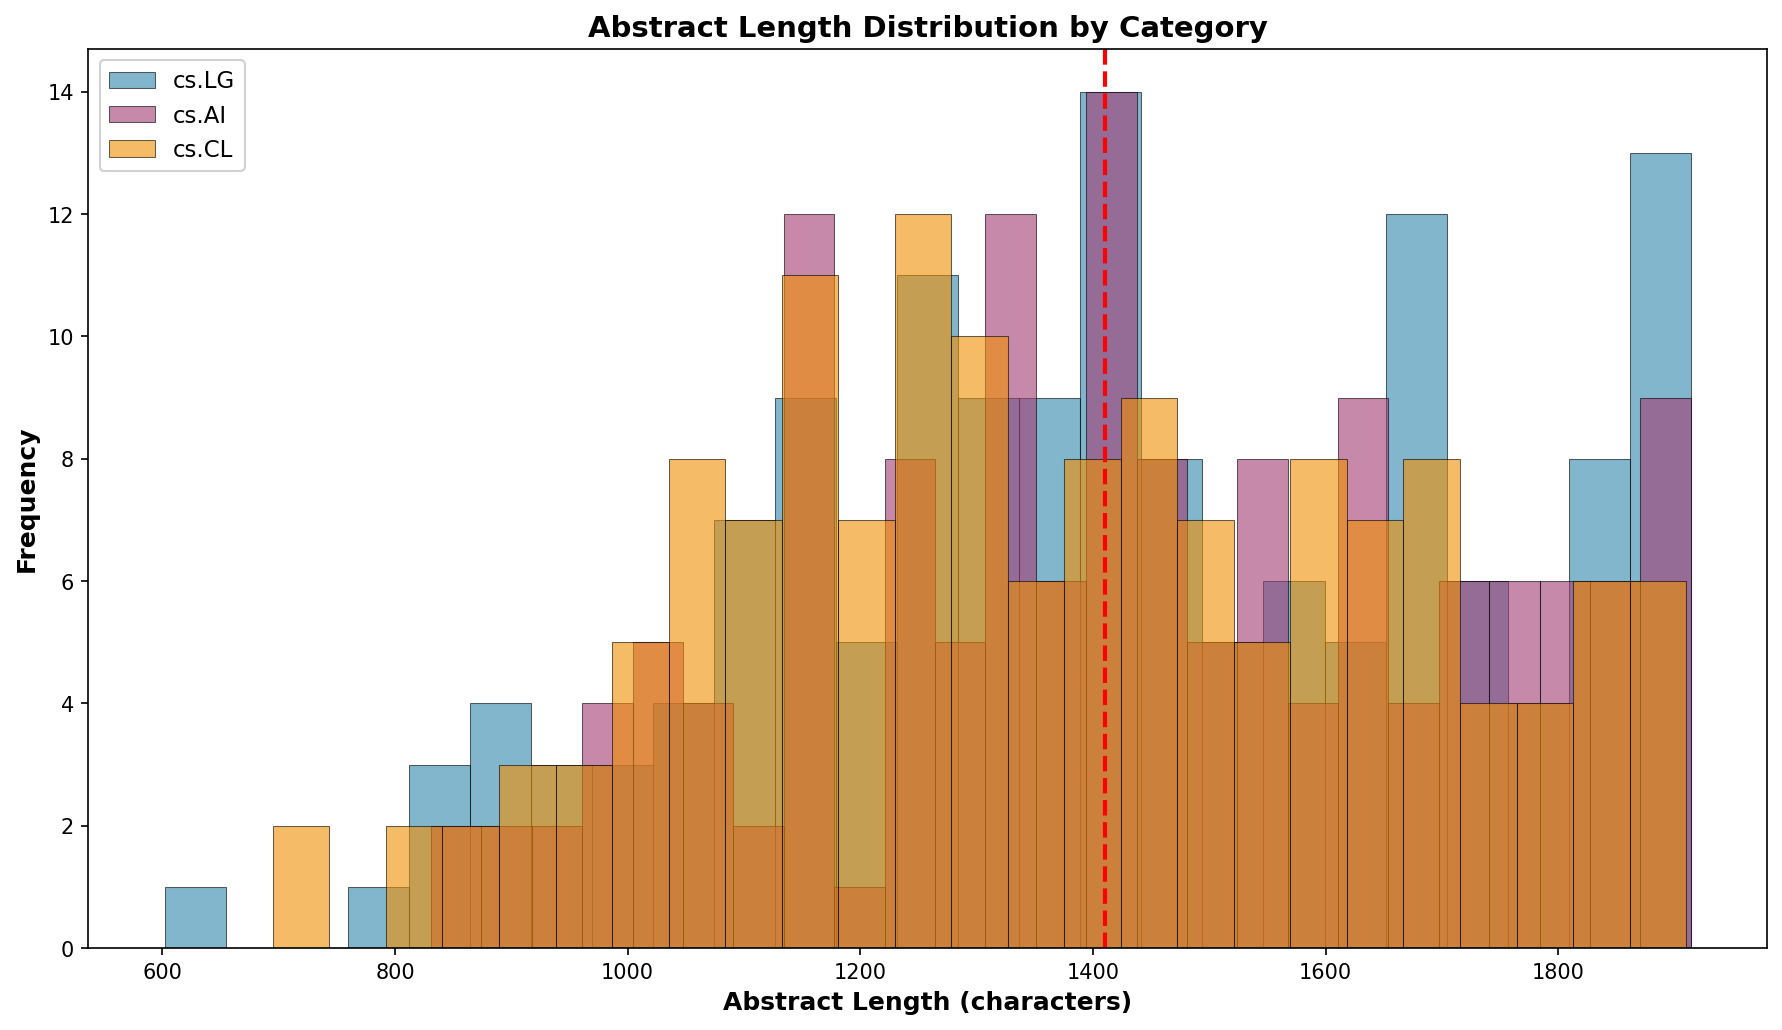

In [3]:
# Abstract length distribution
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('data/arxiv_papers.csv')
df['abstract_length'] = df['abstract'].str.len()
fig, ax = plt.subplots(figsize=(12,7))
for i, cat in enumerate(['cs.LG','cs.AI','cs.CL']):
    subset = df[df['primary_category']==cat]['abstract_length']
    ax.hist(subset, bins=25, alpha=0.6, label=cat)
ax.set_title('Abstract Length Distribution by Category')
ax.legend()
plt.show()

## Figure 3: Top 20 Keywords

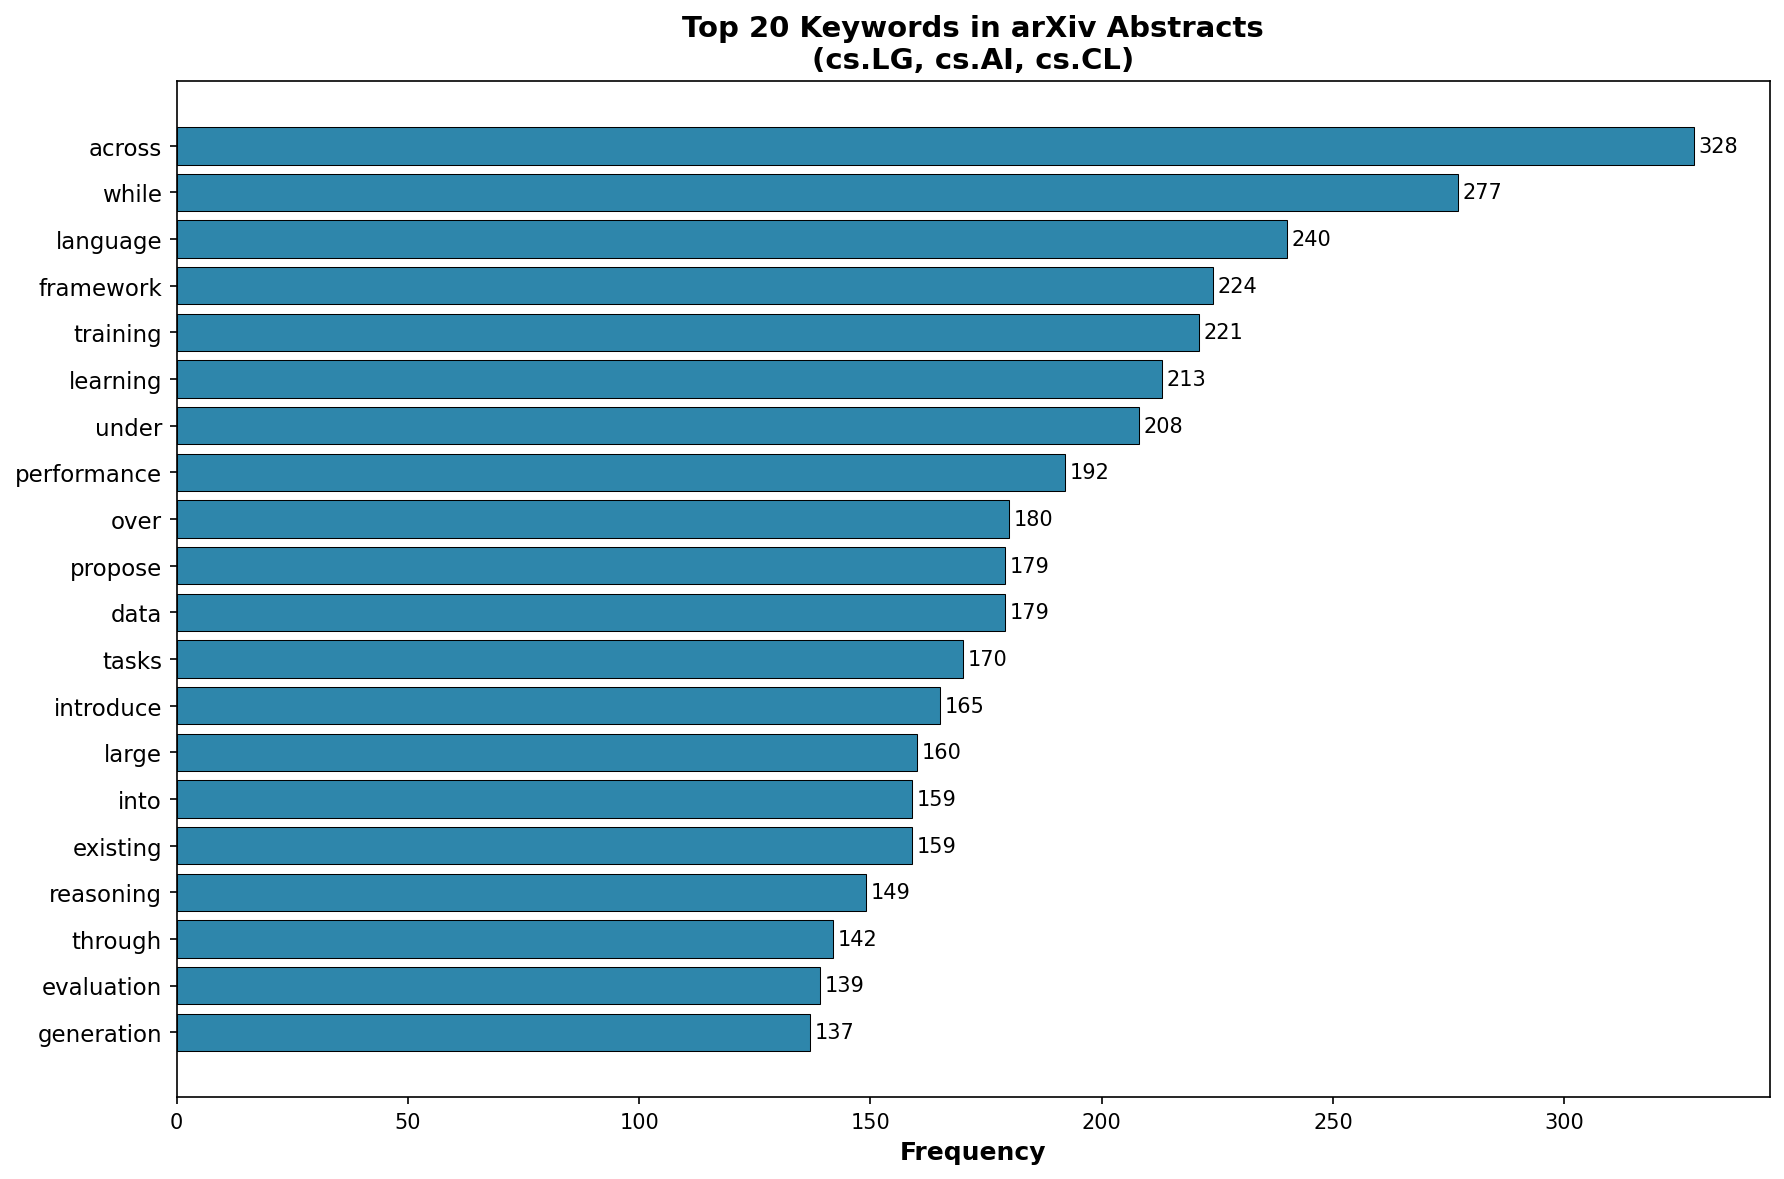

In [4]:
# Top keywords
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
df = pd.read_csv('data/arxiv_papers.csv')
words = [w for abstract in df['abstract'] for w in abstract.lower().split() if len(w)>4]
top = Counter(words).most_common(20)
fig, ax = plt.subplots(figsize=(12,8))
ax.barh(range(len(top)), [c for _,c in top], color='#2E86AB')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([w for w,_ in top])
ax.invert_yaxis()
ax.set_title('Top 20 Keywords')
plt.show()

## Figure 4: Publication Timeline

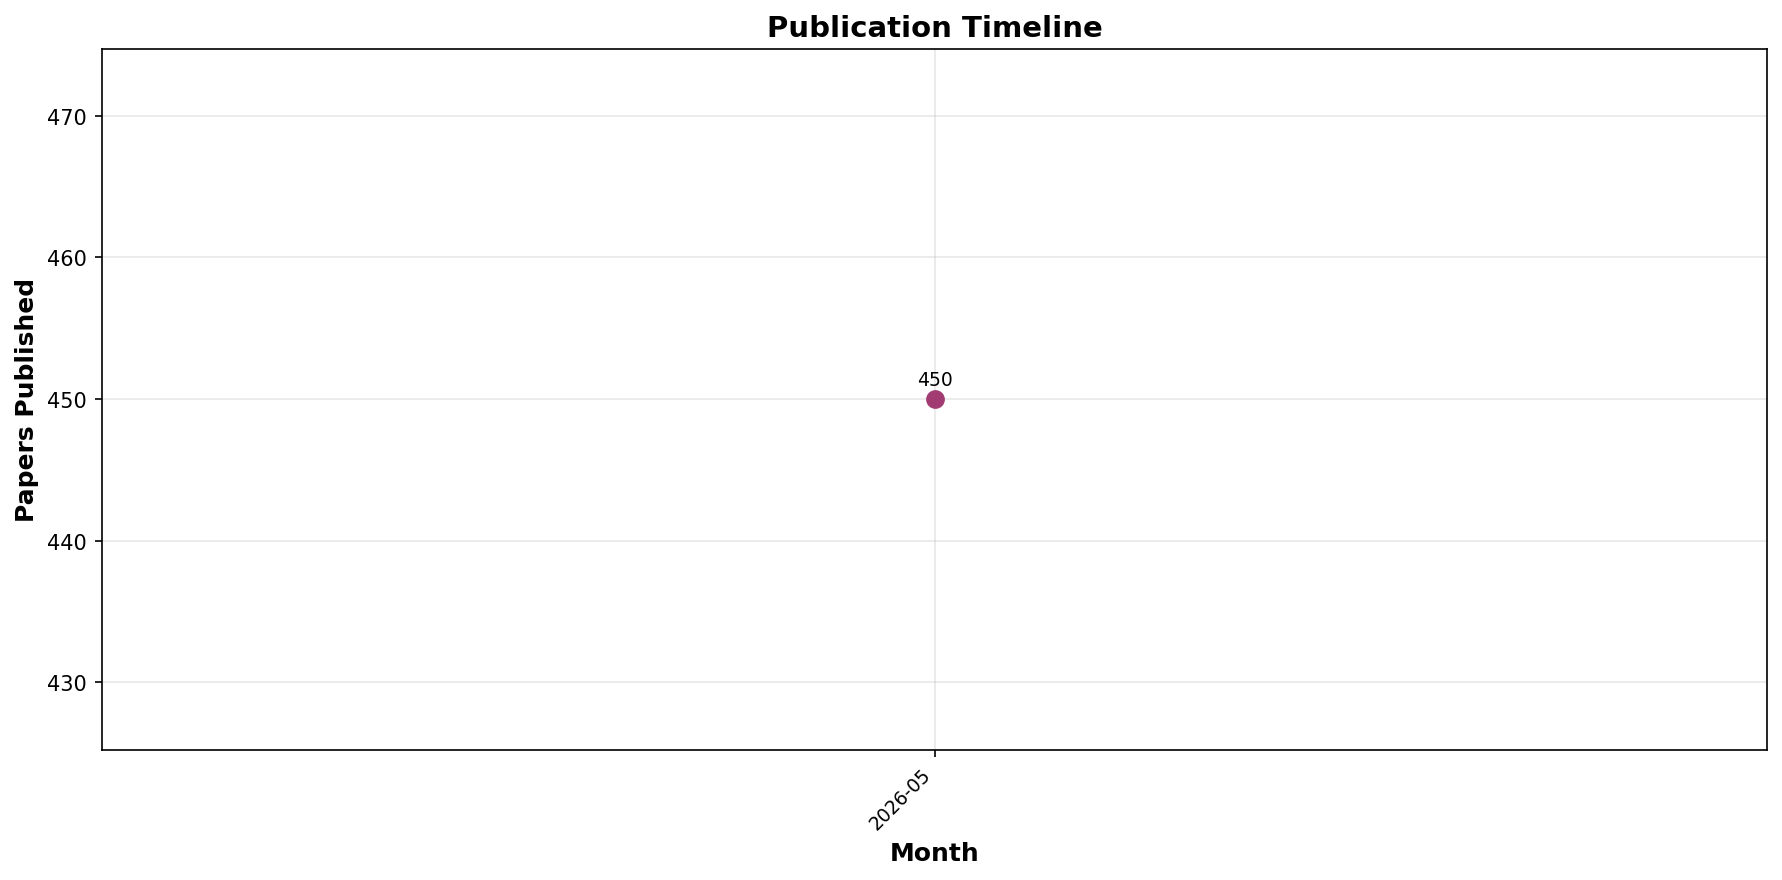

In [5]:
# Publication timeline
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('data/arxiv_papers.csv')
df['published_date'] = pd.to_datetime(df['published'])
monthly = df.groupby(df['published_date'].dt.to_period('M')).size()
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(len(monthly)), monthly.values, marker='o', color='#A23B72')
ax.set_title('Publication Timeline')
plt.show()